#Image Correction for -
- Denoising
- Contrast/brightness normalization
- Super‑resolution / de‑aliasing

##Models good for increasing image resolution(also used/tested on SEMs)
- GAN ( https://www.nature.com/articles/s41598-019-48444-2 ) (SRGAN -> ESRGAN) // image hallucination risk, hence avoiding for right now
for the initial MVP starting with Unet , NAFNet and Restormer and benchmarking performance to choose the better model
- NAFNet > Restormer >HiNet, CGNet (high validation scores but distortion )
----------------------------------------------------------------------------
#### <b> can try out i/p --> NAFNet/UNet/Restormer/DnCNN --> GAN --> Image w/ high resolution and denoising in v2


### Check for GPU

### Install Dependencies

In [2]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install pytorch-msssim

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install albumentations

Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
import torch.nn as nn
import torchvision
import torch.nn.functional as f
from torch.nn.functional import relu


In [2]:
from torchvision import transforms
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2    

In [3]:
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [5]:
torch.manual_seed(7)


### CV Lab Dataset

### Loading DataSet

In [6]:
from PIL import Image
import tifffile
img = Image.open('/Users/tjsss/Desktop/bharatAtomic/bA/dataset/training.tif')


In [7]:
img = tifffile.imread('/Users/tjsss/Desktop/bharatAtomic/bA/dataset/training.tif')

preprocess = transforms.Compose([
    transforms.Resize((1024, 1024)),
    transforms.ToTensor() 
])

training_tensors = []

# 2. Open the multi-page TIFF file
with tifffile.TiffFile('/Users/tjsss/Desktop/bharatAtomic/bA/dataset/training.tif') as tif:
    for page in tif.pages:
        # Get the page as a numpy array
        img_array = page.asarray()
        
        # Convert numpy array to PIL Image
        pil_img = Image.fromarray(img_array)
        
        # Apply transforms (resizes to 1024x1024 and creates a [1, 1024, 1024] tensor)
        tensor_img = preprocess(pil_img)
        
        training_tensors.append(tensor_img)

# 3. Stack all pages into a single batch tensor: [Pages, Channels, Height, Width]
# Output shape will be: [Num_Pages, 1, 1024, 1024]
final_dataset_tensor = torch.stack(training_tensors)
print(final_dataset_tensor.shape)

testing_tensors = []
with tifffile.TiffFile('/Users/tjsss/Desktop/bharatAtomic/bA/dataset/training.tif') as tif:
    for page in tif.pages:
        img_array = page.asarray()
        pil_img = Image.fromarray(img_array)
        tensor_img = preprocess(pil_img)
        testing_tensors.append(tensor_img)
        
final_testing_tensor = torch.stack(testing_tensors)
print(final_testing_tensor.shape)

torch.Size([165, 1, 1024, 1024])
torch.Size([165, 1, 1024, 1024])


In [8]:
from random import randint


img = torchvision.transforms.ToPILImage()(final_dataset_tensor[randint(0,164)-1][0])
img.show()

In [9]:
train_arrays = []
with tifffile.TiffFile('/Users/tjsss/Desktop/bharatAtomic/bA/dataset/training.tif') as tif:
    for page in tif.pages:
        # Get the page as a numpy array
        train_img_array = page.asarray()
        train_arrays.append(train_img_array)

test_arrays = []
with tifffile.TiffFile('/Users/tjsss/Desktop/bharatAtomic/bA/dataset/testing.tif') as tif:
    for page in tif.pages:
        test_img_array = page.asarray()
        test_arrays.append(test_img_array)

In [10]:
len(test_arrays) 

165

In [11]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [34]:

train_transform= A.Compose([
    A.GaussianBlur(blur_limit=(3, 7), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.RandomGamma(gamma_limit=(80, 120), p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Affine(translate_percent=(0.1, 0.1), scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),
    A.Normalize(mean=0, std=1),
    ToTensorV2()
])

test_transform = A.Compose([
    A.Normalize(mean=0, std=1),
    ToTensorV2()
])

class CustomData(Dataset):
    def __init__(self, images, transform = None, repeats = 6, training = False):
        self.images = images
        self.transform = transform
        self.repeats = repeats
        self.training = training

    def __len__(self):
        return len(self.images) * self.repeats
    
    def __getitem__(self, idx):
        if self.training:
            img_idx = idx % len(self.images)
            image = self.images[img_idx]
            
            x = image
        else:
            image = self.images[idx]
            x = image
        if self.transform:
            x = self.transform(image=image)['image']
            y = self.transform(image=image)['image']
        
        return x, y

In [35]:
train_dataset = CustomData(train_arrays, transform=train_transform , training=True)
test_dataset  = CustomData(test_arrays, transform=test_transform , repeats = 1, training=False,)
len(train_dataset)


990

In [38]:
all_train_tensors = []
all_train_labels = []
for i in range(len(train_dataset)):
    x, y = train_dataset[i]
    all_train_tensors.append(x)
    all_train_labels.append(y)

train_tensors = torch.stack(all_train_tensors)
train_labels = torch.stack(all_train_labels)

torch.save({'images': train_tensors, 'labels': train_labels}, 'train_dataset.pt')
torch.save({'images': torch.stack([test_dataset[i][0] for i in range(len(test_dataset))]),
            'labels': torch.stack([test_dataset[i][1] for i in range(len(test_dataset))])}, 
           'test_dataset.pt')

In [36]:
len(test_dataset)

165

In [37]:
from torch.utils.data import DataLoader, random_split

In [16]:
def load_data(train_dataset, test_dataset, batch_size, val_ratio=0.2):
    n = len(train_dataset)
    val_size = int(n * val_ratio)
    train_size = n - val_size

    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


### Loss Function

In [17]:
from pytorch_msssim import ssim, ms_ssim, SSIM, MS_SSIM

In [18]:
def calc_loss(pred, target, theta = 0.2):
  ssim_fn = ssim(pred, target, data_range=1.0, size_average=True)
  mse_fn = nn.MSELoss()
  loss = (1-theta)*mse_fn(pred, target) + theta*ssim_fn
  return loss

### Training Fuction

In [29]:
def train_eval(model, num_epochs, train_loader, test_loader , lr = 0.001 , wt_decay = 0.005, theta=0.4):

  optimizer = optim.Adam(model.parameters(), lr=lr , weight_decay=wt_decay)

  total_loss_train = 0
  for epoch in range(num_epochs):
    model.train()
    for batch_features, batch_labels in train_loader:
      batch_features, batch_labels = batch_features.to(device) , batch_labels.to(device)
      output = model(batch_features)
      optimizer.zero_grad()
      loss = calc_loss(output , batch_labels , theta)
      total_loss_train += loss.item()
      loss.backward()
      optimizer.step()
      
    avg_loss = total_loss_train / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

  model.eval()
  total_loss = 0
  with torch.no_grad():
    for batch_features, batch_labels in test_loader:
      batch_features, batch_labels = batch_features.to(device) , batch_labels.to(device)
      output = model(batch_features)
      loss = calc_loss(output , batch_labels , theta)
      total_loss += loss.item()
    print(total_loss/len(test_loader))

## UNet

### Architecture

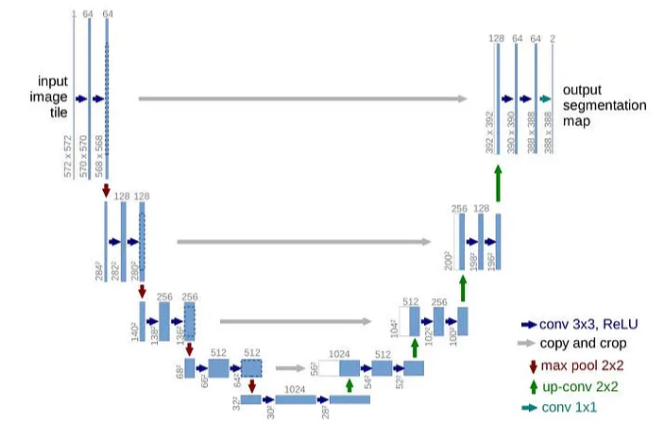

In [30]:
# ( https://medium.com/data-science/cook-your-first-u-net-in-pytorch-b3297a844cf3 )

class UNet(nn.Module):
  def __init__(self, num_ip=3, n_class= 1):
    super(UNet, self).__init__()
      # Encoder
      # In the encoder, convolutional layers with the Conv2d function are used to extract features from the input image.
      # Each block in the encoder consists of two convolutional layers followed by a max-pooling layer, with the exception of the last block which does not include a max-pooling layer.
      # -------
      # input: 572x572x3
    self.e11 = nn.Conv2d(num_ip, 64, kernel_size=3, padding=1) # output: 570x570x64
    self.e12 = nn.Conv2d(64, 64, kernel_size=3, padding=1) # output: 568x568x64
    self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # output: 284x284x64

      # input: 284x284x64
    self.e21 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # output: 282x282x128
    self.e22 = nn.Conv2d(128, 128, kernel_size=3, padding=1) # output: 280x280x128
    self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # output: 140x140x128

      # input: 140x140x128
    self.e31 = nn.Conv2d(128, 256, kernel_size=3, padding=1) # output: 138x138x256
    self.e32 = nn.Conv2d(256, 256, kernel_size=3, padding=1) # output: 136x136x256
    self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) # output: 68x68x256

      # input: 68x68x256
    self.e41 = nn.Conv2d(256, 512, kernel_size=3, padding=1) # output: 66x66x512
    self.e42 = nn.Conv2d(512, 512, kernel_size=3, padding=1) # output: 64x64x512
    self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2) # output: 32x32x512

      # input: 32x32x512
    self.e51 = nn.Conv2d(512, 1024, kernel_size=3, padding=1) # output: 30x30x1024
    self.e52 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1) # output: 28x28x1024  BOTTLENECK


      # Decoder
    self.upconv1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
    self.d11 = nn.Conv2d(1024, 512, kernel_size=3, padding=1)
    self.d12 = nn.Conv2d(512, 512, kernel_size=3, padding=1)

    self.upconv2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
    self.d21 = nn.Conv2d(512, 256, kernel_size=3, padding=1)
    self.d22 = nn.Conv2d(256, 256, kernel_size=3, padding=1)

    self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
    self.d31 = nn.Conv2d(256, 128, kernel_size=3, padding=1)
    self.d32 = nn.Conv2d(128, 128, kernel_size=3, padding=1)

    self.upconv4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
    self.d41 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
    self.d42 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

    #   #adding layers to make it one channel output
    # self.d43 = nn.Conv2d(64, 32 , kernel_size  = 3, padding = 1)
    # self.d44 = nn.Conv2d(32,16 , kernel_size  = 3, padding = 1)
    # self.d45 = nn.Conv2d(16, 8, kernel_size=3 , padding = 1)
    # self.d46 = nn.Conv2d(8 , 1 , kernel_size=3 , padding = 3)

      # Output layer
    self.outconv = nn.Conv2d(64, n_class, kernel_size=1)


  def forward(self, x):
      # Encoder
        xe11 = relu(self.e11(x))
        xe12 = relu(self.e12(xe11))
        xp1 = self.pool1(xe12)

        xe21 = relu(self.e21(xp1))
        xe22 = relu(self.e22(xe21))
        xp2 = self.pool2(xe22)

        xe31 = relu(self.e31(xp2))
        xe32 = relu(self.e32(xe31))
        xp3 = self.pool3(xe32)

        xe41 = relu(self.e41(xp3))
        xe42 = relu(self.e42(xe41))
        xp4 = self.pool4(xe42)

        xe51 = relu(self.e51(xp4))
        xe52 = relu(self.e52(xe51))

        # Decoder
        xu1 = self.upconv1(xe52)
        xu11 = torch.cat([xu1, xe42], dim=1)
        xd11 = relu(self.d11(xu11))
        xd12 = relu(self.d12(xd11))

        xu2 = self.upconv2(xd12)
        xu22 = torch.cat([xu2, xe32], dim=1)
        xd21 = relu(self.d21(xu22))
        xd22 = relu(self.d22(xd21))

        xu3 = self.upconv3(xd22)
        xu33 = torch.cat([xu3, xe22], dim=1)
        xd31 = relu(self.d31(xu33))
        xd32 = relu(self.d32(xd31))

        xu4 = self.upconv4(xd32)
        xu44 = torch.cat([xu4, xe12], dim=1)
        xd41 = relu(self.d41(xu44))
        xd42 = relu(self.d42(xd41))

        # Output layer
        out = self.outconv(xd42)

        return out

In [31]:

train_loader, val_loader, _loader = load_data(train_dataset, test_dataset, 2)


In [32]:
batch_features, batch_labels = next(iter(train_loader))
print(f"Features dtype: {batch_features.dtype}")
print(f"Features shape: {batch_features.shape}")
print(f"Labels dtype: {batch_labels.dtype}")

Features dtype: torch.float32
Features shape: torch.Size([2, 1, 768, 1024])
Labels dtype: torch.float32


In [39]:
train_eval(UNet(num_ip =1 , n_class =1), 25, train_loader, val_loader, lr=0.001, wt_decay=0.005, theta=0.4)

KeyboardInterrupt: 

## Restormer

In [83]:
class MDTA(nn.Module):
    def __init__(self, channels, num_heads):
        super(MDTA, self).__init__()
        self.num_heads = num_heads ## number of channels per Q, K
        self.temperature = nn.Parameter(torch.ones(1, num_heads, 1, 1))

        self.qkv = nn.Conv2d(channels, channels * 3, kernel_size=1, bias=False)
        self.qkv_conv = nn.Conv2d(channels * 3, channels * 3, kernel_size=3, padding=1, groups=channels * 3, bias=False)
        self.project_out = nn.Conv2d(channels, channels, kernel_size=1, bias=False)

    def forward(self, x):
        b, c, h, w = x.shape
        q, k, v = self.qkv_conv(self.qkv(x)).chunk(3, dim=1)

        q = q.reshape(b, self.num_heads, -1, h * w)
        k = k.reshape(b, self.num_heads, -1, h * w)
        v = v.reshape(b, self.num_heads, -1, h * w)
        q, k = f.normalize(q, dim=-1), f.normalize(k, dim=-1)

        attn = torch.softmax(torch.matmul(q, k.transpose(-2, -1).contiguous()) * self.temperature, dim=-1)
        out = self.project_out(torch.matmul(attn, v).reshape(b, -1, h, w))
        return out


class GDFN(nn.Module):
    def __init__(self, channels, expansion_factor):
        super(GDFN, self).__init__()

        hidden_channels = int(channels * expansion_factor)
        self.project_in = nn.Conv2d(channels, hidden_channels * 2, kernel_size=1, bias=False)
        self.conv = nn.Conv2d(hidden_channels * 2, hidden_channels * 2, kernel_size=3, padding=1,
                              groups=hidden_channels * 2, bias=False)
        self.project_out = nn.Conv2d(hidden_channels, channels, kernel_size=1, bias=False)

    def forward(self, x):
        x1, x2 = self.conv(self.project_in(x)).chunk(2, dim=1)
        x = self.project_out(f.gelu(x1) * x2)
        return x


class TransformerBlock(nn.Module):
    def __init__(self, channels, num_heads, expansion_factor):
        super(TransformerBlock, self).__init__()

        self.norm1 = nn.LayerNorm(channels)
        self.attn = MDTA(channels, num_heads)
        self.norm2 = nn.LayerNorm(channels)
        self.ffn = GDFN(channels, expansion_factor)

    def forward(self, x):
        b, c, h, w = x.shape
        x = x + self.attn(self.norm1(x.reshape(b, c, -1).transpose(-2, -1).contiguous()).transpose(-2, -1)
                          .contiguous().reshape(b, c, h, w))
        x = x + self.ffn(self.norm2(x.reshape(b, c, -1).transpose(-2, -1).contiguous()).transpose(-2, -1)
                         .contiguous().reshape(b, c, h, w))
        return x


class DownSample(nn.Module):
    def __init__(self, channels):
        super(DownSample, self).__init__()
        self.body = nn.Sequential(nn.Conv2d(channels, channels // 2, kernel_size=3, padding=1, bias=False),
                                  nn.PixelUnshuffle(2))

    def forward(self, x):
        return self.body(x)


class UpSample(nn.Module):
    def __init__(self, channels):
        super(UpSample, self).__init__()
        self.body = nn.Sequential(nn.Conv2d(channels, channels * 2, kernel_size=3, padding=1, bias=False),
                                  nn.PixelShuffle(2))

    def forward(self, x):
        return self.body(x)


class Restormer(nn.Module):
    def __init__(self, num_blocks=[4, 6, 6, 8], num_heads=[1, 2, 4, 8], channels=[48, 96, 192, 384], num_refinement=4,
                 expansion_factor=2.66):
        super(Restormer, self).__init__()

        self.embed_conv = nn.Conv2d(3, channels[0], kernel_size=3, padding=1, bias=False)

        self.encoders = nn.ModuleList([nn.Sequential(*[TransformerBlock(
            num_ch, num_ah, expansion_factor) for _ in range(num_tb)]) for num_tb, num_ah, num_ch in
                                       zip(num_blocks, num_heads, channels)])
        # the number of down sample or up sample == the number of encoder - 1
        self.downs = nn.ModuleList([DownSample(num_ch) for num_ch in channels[:-1]])
        self.ups = nn.ModuleList([UpSample(num_ch) for num_ch in list(reversed(channels))[:-1]])
        # the number of reduce block == the number of decoder - 1
        self.reduces = nn.ModuleList([nn.Conv2d(channels[i], channels[i - 1], kernel_size=1, bias=False)
                                      for i in reversed(range(2, len(channels)))])
        # the number of decoder == the number of encoder - 1
        self.decoders = nn.ModuleList([nn.Sequential(*[TransformerBlock(channels[2], num_heads[2], expansion_factor)
                                                       for _ in range(num_blocks[2])])])
        self.decoders.append(nn.Sequential(*[TransformerBlock(channels[1], num_heads[1], expansion_factor)
                                             for _ in range(num_blocks[1])]))
        # the channel of last one is not change
        self.decoders.append(nn.Sequential(*[TransformerBlock(channels[1], num_heads[0], expansion_factor)
                                             for _ in range(num_blocks[0])]))

        self.refinement = nn.Sequential(*[TransformerBlock(channels[1], num_heads[0], expansion_factor)
                                          for _ in range(num_refinement)])
        self.output = nn.Conv2d(channels[1], 3, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        fo = self.embed_conv(x)
        out_enc1 = self.encoders[0](fo)
        out_enc2 = self.encoders[1](self.downs[0](out_enc1))
        out_enc3 = self.encoders[2](self.downs[1](out_enc2))
        out_enc4 = self.encoders[3](self.downs[2](out_enc3))

        out_dec3 = self.decoders[0](self.reduces[0](torch.cat([self.ups[0](out_enc4), out_enc3], dim=1)))
        out_dec2 = self.decoders[1](self.reduces[1](torch.cat([self.ups[1](out_dec3), out_enc2], dim=1)))
        fd = self.decoders[2](torch.cat([self.ups[2](out_dec2), out_enc1], dim=1))
        fr = self.refinement(fd)
        out = self.output(fr) + x
        return out

## NAFNet

In [ ]:
class SimpleGate(nn.Module):
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        return x1 * x2

class NAFBlock(nn.Module):
    def __init__(self, c, DW_Expand=2, FFN_Expand=2, drop_out_rate=0.):
        super().__init__()
        dw_channel = c * DW_Expand
        self.conv1 = nn.Conv2d(in_channels=c, out_channels=dw_channel, kernel_size=1, padding=0, stride=1, groups=1, bias=True)
        self.conv2 = nn.Conv2d(in_channels=dw_channel, out_channels=dw_channel, kernel_size=3, padding=1, stride=1, groups=dw_channel,
                               bias=True)
        self.conv3 = nn.Conv2d(in_channels=dw_channel // 2, out_channels=c, kernel_size=1, padding=0, stride=1, groups=1, bias=True)

        # Simplified Channel Attention
        self.sca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels=dw_channel // 2, out_channels=dw_channel // 2, kernel_size=1, padding=0, stride=1,
                      groups=1, bias=True),
        )

        # SimpleGate
        self.sg = SimpleGate()

        ffn_channel = FFN_Expand * c
        self.conv4 = nn.Conv2d(in_channels=c, out_channels=ffn_channel, kernel_size=1, padding=0, stride=1, groups=1, bias=True)
        self.conv5 = nn.Conv2d(in_channels=ffn_channel // 2, out_channels=c, kernel_size=1, padding=0, stride=1, groups=1, bias=True)

        self.norm1 = LayerNorm2d(c)
        self.norm2 = LayerNorm2d(c)

        self.dropout1 = nn.Dropout(drop_out_rate) if drop_out_rate > 0. else nn.Identity()
        self.dropout2 = nn.Dropout(drop_out_rate) if drop_out_rate > 0. else nn.Identity()

        self.beta = nn.Parameter(torch.zeros((1, c, 1, 1)), requires_grad=True)
        self.gamma = nn.Parameter(torch.zeros((1, c, 1, 1)), requires_grad=True)

    def forward(self, inp):
        x = inp

        x = self.norm1(x)

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.sg(x)
        x = x * self.sca(x)
        x = self.conv3(x)

        x = self.dropout1(x)

        y = inp + x * self.beta

        x = self.conv4(self.norm2(y))
        x = self.sg(x)
        x = self.conv5(x)

        x = self.dropout2(x)

        return y + x * self.gamma


class NAFNet(nn.Module):

    def __init__(self, img_channel=3, width=16, middle_blk_num=1, enc_blk_nums=[], dec_blk_nums=[]):
        super().__init__()

        self.intro = nn.Conv2d(in_channels=img_channel, out_channels=width, kernel_size=3, padding=1, stride=1, groups=1,
                              bias=True)
        self.ending = nn.Conv2d(in_channels=width, out_channels=img_channel, kernel_size=3, padding=1, stride=1, groups=1,
                              bias=True)

        self.encoders = nn.ModuleList()
        self.decoders = nn.ModuleList()
        self.middle_blks = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()

        chan = width
        for num in enc_blk_nums:
            self.encoders.append(
                nn.Sequential(
                    *[NAFBlock(chan) for _ in range(num)]
                )
            )
            self.downs.append(
                nn.Conv2d(chan, 2*chan, 2, 2)
            )
            chan = chan * 2

        self.middle_blks = \
            nn.Sequential(
                *[NAFBlock(chan) for _ in range(middle_blk_num)]
            )

        for num in dec_blk_nums:
            self.ups.append(
                nn.Sequential(
                    nn.Conv2d(chan, chan * 2, 1, bias=False),
                    nn.PixelShuffle(2)
                )
            )
            chan = chan // 2
            self.decoders.append(
                nn.Sequential(
                    *[NAFBlock(chan) for _ in range(num)]
                )
            )

        self.padder_size = 2 ** len(self.encoders)

    def forward(self, inp):
        B, C, H, W = inp.shape
        inp = self.check_image_size(inp)

        x = self.intro(inp)

        encs = []

        for encoder, down in zip(self.encoders, self.downs):
            x = encoder(x)
            encs.append(x)
            x = down(x)

        x = self.middle_blks(x)

        for decoder, up, enc_skip in zip(self.decoders, self.ups, encs[::-1]):
            x = up(x)
            x = x + enc_skip
            x = decoder(x)

        x = self.ending(x)
        x = x + inp

        return x[:, :, :H, :W]

    def check_image_size(self, x):
        _, _, h, w = x.size()
        mod_pad_h = (self.padder_size - h % self.padder_size) % self.padder_size
        mod_pad_w = (self.padder_size - w % self.padder_size) % self.padder_size
        x = F.pad(x, (0, mod_pad_w, 0, mod_pad_h))
        return x

class NAFNetLocal(Local_Base, NAFNet):
    def __init__(self, *args, train_size=(1, 3, 256, 256), fast_imp=False, **kwargs):
        Local_Base.__init__(self)
        NAFNet.__init__(self, *args, **kwargs)

        N, C, H, W = train_size
        base_size = (int(H * 1.5), int(W * 1.5))

        self.eval()
        with torch.no_grad():
            self.convert(base_size=base_size, train_size=train_size, fast_imp=fast_imp)


In [ ]:
from PIL import Image
from nafnetlib import DeblurProcessor, DenoiseProcessor

# Initialize the deblurring processor
db_processor = DeblurProcessor(
    model_id="reds_width64",
    model_dir="/absolute/path/to/model/directory",
    device="cuda"
)

# Print available models
print(db_processor.available_models())

# Initialize the denoising processor
db_processor = DenoiseProcessor(
    model_id="sidd_width64",
    model_dir="/absolute/path/to/model/directory",
    device="cuda"
)

# Load image for processing
img_path = "path/to/image/file"
image = Image.open(img_path)

# Process the image (e.g., deblur or denoise)
db_processor.process(image).show()


Supported Models
The following models are available for different image restoration tasks:

Image Deblurring (GoPro):
Models: gopro_width64, gopro_width32

Image Denoising (SIDD):
Models: sidd_width64, sidd_width32

Image Deblurring with JPEG Artifacts (REDS):
Models: reds_width64

These models are derived from the megvii-research/nafnet GitHub repository.